In [2]:
!pip install networkx
!pip install matplotlib
!pip install tqdm
!pip install pandas
!pip install numpy
!pip install graphviz
!pip install scikit-learn

# Task 1. Algorithm's analysis

In [3]:
import random
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, groupby

from networkx.algorithms import tree
from networkx.algorithms import bellman_ford_predecessor_and_distance
from networkx.algorithms import floyd_warshall_predecessor_and_distance

import numpy.typing as npt

### Generating graph

In [4]:

# You can use this function to generate a random graph with 'num_of_nodes'
# nodes and 'completeness' probability of an edge between any two nodes
# If 'directed' is True, the graph will be directed
# If 'draw' is True, the graph will be drawn
def gnp_random_connected_graph(num_of_nodes: int,
                               completeness: int,
                               directed: bool = False,
                               draw: bool = False):
    """
    Generates a random graph, similarly to an Erdős-Rényi
    graph, but enforcing that the resulting graph is conneted
    (in case of undirected graphs)
    """


    if directed:
        G = nx.DiGraph()
    else:
        G = nx.Graph()
    edges = combinations(range(num_of_nodes), 2)
    G.add_nodes_from(range(num_of_nodes))

    for _, node_edges in groupby(edges, key = lambda x: x[0]):
        node_edges = list(node_edges)
        random_edge = random.choice(node_edges)
        if random.random() < 0.5:
            random_edge = random_edge[::-1]
        G.add_edge(*random_edge)
        for e in node_edges:
            if random.random() < completeness:
                G.add_edge(*e)

    for (u,v,w) in G.edges(data=True):
        w['weight'] = random.randint(-5, 20)

    if draw:
        plt.figure(figsize=(10,6))
        if directed:
            # draw with edge weights
            pos = nx.arf_layout(G)
            nx.draw(G,pos, node_color='lightblue',
                    with_labels=True,
                    node_size=500,
                    arrowsize=20,
                    arrows=True)
            labels = nx.get_edge_attributes(G,'weight')
            nx.draw_networkx_edge_labels(G, pos,edge_labels=labels)

        else:
            nx.draw(G, node_color='lightblue',
                with_labels=True,
                node_size=500)

    return G

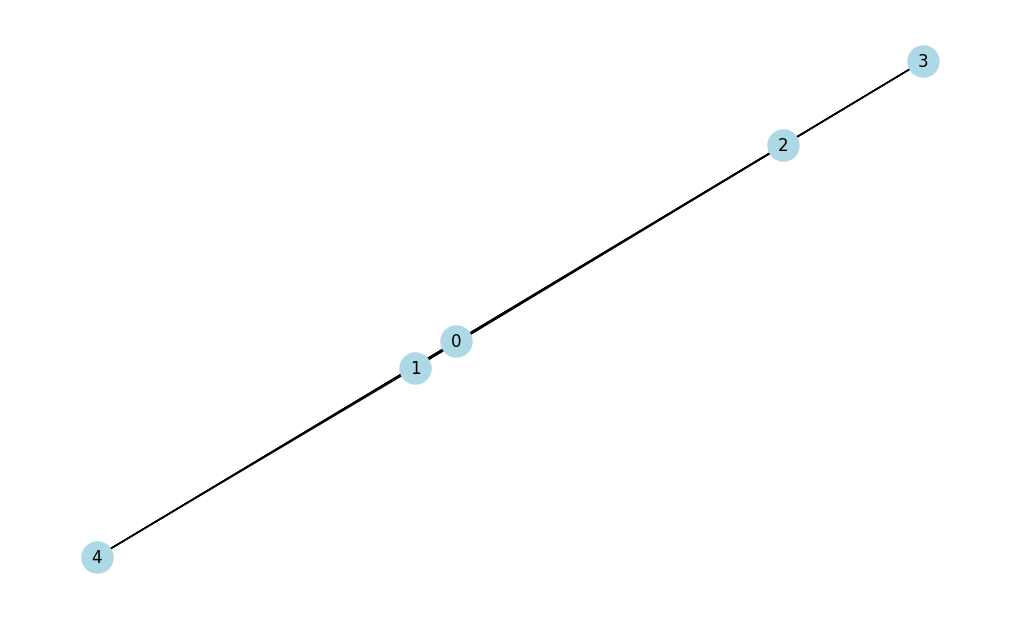

In [5]:
G = gnp_random_connected_graph(5, 0.8, False, True)

## Subtask 1.1 (1 point)

### Kruskal's algorithm

#### nx implementation

In [6]:
mstk = tree.minimum_spanning_tree(G, algorithm="kruskal")

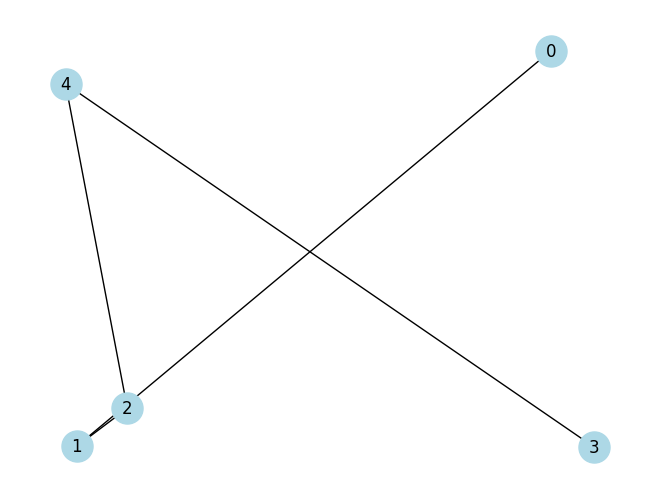

In [7]:
nx.draw(mstk, node_color='lightblue',
        with_labels=True,
        node_size=500)

In [8]:
mstk.edges(), len(mstk.edges())

(EdgeView([(0, 1), (1, 2), (2, 4), (3, 4)]), 4)

#### Your implementation

In [ ]:
def kruskal_algorithm(graph):
    """
    Finds the Minimum Spanning Tree (MST) of a graph using Kruskal's algorith

    This function iterates through all edges of the graph, sorted by weight
    and adds them to the MST if they do not form a cycle.
    It uses a disjoint-set data structure logic to track connected components

    :param graph: A NetworkX Graph object containing weighted edges
                  Edges should have a 'weight' attribute
    :return: A new NetworkX Graph object representing the Minimum Spanning Tree
             The returned graph contains the subset of edges that connects
             all vertices with the minimum possible total edge weight
    """
    parent = {}
    edges = []
    for node1, node2, weight in graph.edges(data='weight'):
        parent[node1] = node1
        parent[node2] = node2
        nodes = (node1, node2)
        edges.append((nodes, weight))
    edges.sort(key=lambda x: x[1])

    minimum_spanning_tree = []
    for edge, weight in edges:
        root1 = edge[0]
        while parent[root1] != root1:
            root1 = parent[root1]
        root2 = edge[1]
        while parent[root2] != root2:
            root2 = parent[root2]
        if root1 != root2:
            parent[root1] = root2
            minimum_spanning_tree.append((edge, weight))

    final_mst = nx.Graph()
    for edge, weight in minimum_spanning_tree:
        final_mst.add_edge(edge[0], edge[1], weight=weight)
    return final_mst

### Prim's algorithm

#### nx implementation

In [10]:
mstp = tree.minimum_spanning_tree(G, algorithm="prim")

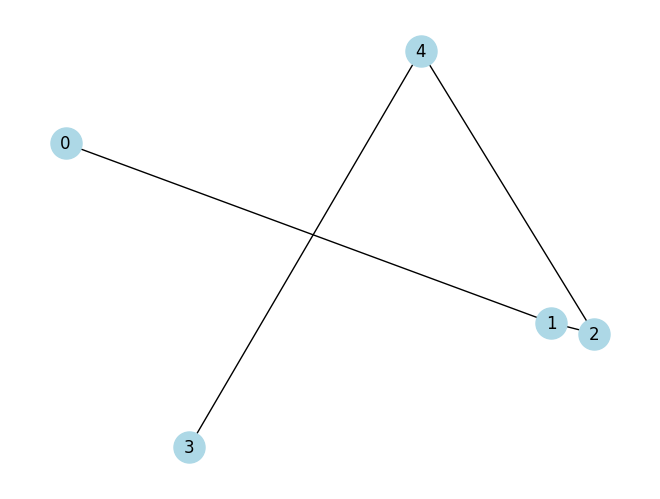

In [11]:
nx.draw(mstp, node_color='lightblue',
        with_labels=True,
        node_size=500)

In [12]:
mstp.edges(), len(mstp.edges())

(EdgeView([(0, 1), (1, 2), (2, 4), (3, 4)]), 4)

#### Your implementation

In [ ]:
def prim_algoritm(graph):
    """
    Finds the Minimum Spanning Tree (MST) using Prim's algorithm

    This implementation manually selects the edge with the minimum weight
    from a list of potential edges at each step, ensuring that no cycles
    are formed. It assumes the input graph is connected and edges have weights

    :param graph: A NetworkX Graph object. Edges should have a 'weight' attribute
    :return: A new NetworkX Graph object representing the Minimum Spanning Tree
    """
    visited_nodes = set()
    potential_edge = []
    visited_nodes.add(list(graph.nodes())[0])
    for neighbor, attrs in graph[list(graph.nodes())[0]].items():
        weight = attrs.get('weight', 1)
        potential_edge.append((weight, list(graph.nodes())[0], neighbor))

    spanning_tree = nx.Graph()
    while len(visited_nodes) < len(graph.nodes()):
        edges = []
        for edge in potential_edge:
            if edge[2] in visited_nodes:
                continue
            else:
                edges.append(edge)
        smallets_edge = min(edges, key=lambda x: x[0])
        weight, node1, node2 = smallets_edge
        spanning_tree.add_edge(node1, node2, weight=weight)
        visited_nodes.add(node2)

        for neighbor, attrs in graph[node2].items():
            if neighbor not in visited_nodes:
                new_weight = attrs.get('weight', 1)
                potential_edge.append((new_weight, node2, neighbor))
    return spanning_tree

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

## Subtask 1.2 (1 point)

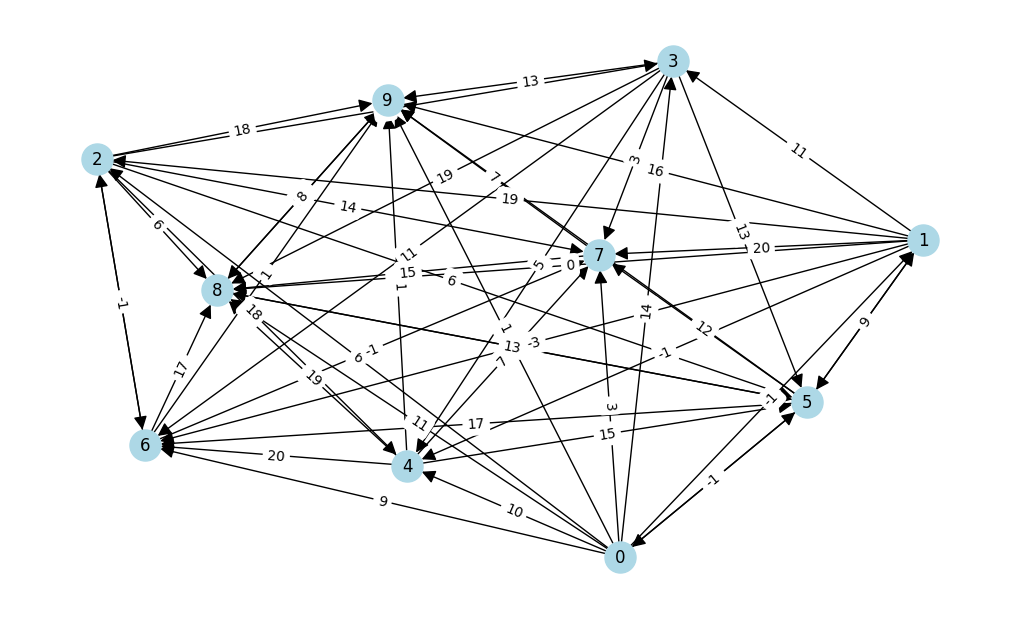

In [14]:
G = gnp_random_connected_graph(10, 1, True, True)

### Bellman-Ford algorithm

#### nx implementation

In [15]:
# pred is a dictionary of predecessors, dist is a dictionary of distances
try:
    pred, dist = bellman_ford_predecessor_and_distance(G, 0)
    for k, v in dist.items():
        print(f"Distance to {k}:", v)
except:
    print("Negative cycle detected")

Distance to 0: 0
Distance to 1: -1
Distance to 2: -5
Distance to 3: -8
Distance to 4: -3
Distance to 5: 1
Distance to 6: -4
Distance to 7: -5
Distance to 8: -2
Distance to 9: -3


#### Your implementation

In [ ]:
def bellman_ford_algorithm(G, start_node: int) -> None | dict:
    """
    Computes the shortest path distances from a given start node to all other
    nodes in a weighted directed graph using the Bellman–Ford algorithm

    The algorithm supports graphs with negative edge weights and is capable of
    detecting negative-weight cycles

    Algorithm stops early if no distance updates occur in an iteration

    Returns dictionary with nodes as keys and distance to them as values

    Also if a negative weight cycle was detected returns None instead of dict

    :param G: Weighted graph
    :param start_node: The node from which algorithm starts
    """
    dist = {}

    for node in G.nodes: # Set distances to infinity, meaning that I cant reach a node
        dist[node] = float("inf")

    dist[start_node] = 0

    for _ in range(len(G.nodes)-1): # This algorithm needs at most n-1 iterations
        old_dist = dist.copy()

        for edge in G.edges(data=True):
            v1 = edge[0]
            v2 = edge[1]
            w = edge[2]["weight"]

            dist[v2] = min(dist[v2], dist[v1] + w)

        if old_dist == dist: # Stop, because algorithm has already found the shortest path
            break


    if old_dist != dist:
        return

    return dist

In [17]:
my_dist = bellman_ford_algorithm(G, 0)

if my_dist is None:
    print("Negative cycle detected")
else:
    for k, v in my_dist.items():
        print(f"Distance to {k}:", v)

Distance to 0: 0
Distance to 1: -1
Distance to 2: -5
Distance to 3: -8
Distance to 4: -3
Distance to 5: 1
Distance to 6: -4
Distance to 7: -5
Distance to 8: -2
Distance to 9: -3


### Floyd-Warshall algorithm

#### nx implementation

In [18]:
# pred is a dictionary of predecessors, dist is a dictionary of distances dictionaries
try:
    pred, dist = floyd_warshall_predecessor_and_distance(G)
    for k, v in dist.items():
        print(f"Distances with {k} source:", dict(v))
except:
    print("Negative cycle detected")

Distances with 0 source: {0: 0, 1: -1, 2: -5, 3: -8, 4: -3, 5: 1, 6: -4, 7: -5, 8: -2, 9: -3}
Distances with 1 source: {1: 0, 2: -4, 3: -7, 4: -2, 5: 2, 6: -3, 7: -4, 8: -1, 9: -2, 0: 1}
Distances with 2 source: {2: 0, 3: -3, 4: 2, 5: 6, 6: 1, 7: 0, 8: 3, 9: 2, 0: 5, 1: 4}
Distances with 3 source: {3: 0, 6: 8, 4: 5, 5: 13, 7: 3, 8: 10, 9: 9, 0: 12, 1: 11, 2: 7}
Distances with 4 source: {4: 0, 5: 15, 6: 10, 7: 7, 8: 12, 9: 11, 0: 14, 1: 13, 2: 9, 3: 6}
Distances with 5 source: {5: 0, 0: -1, 1: -2, 6: -5, 7: -6, 8: -3, 9: -4, 2: -6, 3: -9, 4: -4}
Distances with 6 source: {6: 0, 2: -1, 8: 2, 7: -1, 9: 1, 0: 4, 1: 3, 3: -4, 4: 1, 5: 5}
Distances with 7 source: {7: 0, 9: 7, 8: 15, 0: 27, 1: 26, 2: 22, 3: 19, 4: 24, 5: 28, 6: 23}
Distances with 8 source: {8: 0, 5: 13, 9: 9, 0: 12, 1: 11, 2: 7, 3: 4, 4: 9, 6: 8, 7: 7}
Distances with 9 source: {9: 0, 8: 8, 0: 20, 1: 19, 2: 15, 3: 12, 4: 17, 5: 21, 6: 16, 7: 15}


#### Your implementation

In [ ]:
def floyd_warshall_algorithm(G) -> None | dict:
    """
    Computes the shortest path distances between all pairs of nodes in a
    weighted directed graph using the Floyd–Warshall algorithm

    The algorithm supports negative edge weights and can detect the presence
    of negative-weight cycles

    Returns a 2D distance matrix where dist[i][j] represents the shortest
    path distance from node i to node j

    Also Returns None if a negative-weight cycle is detected

    :param G: Weighted graph
    """
    n = len(G.nodes) # number of nodes in a graph G

    # Set up a distance matrix
    dist = [[float("inf") for _ in range(n)] for _ in range(n)]

    for i in range(n):
        dist[i][i] = 0

    for edge in G.edges(data=True):
        dist[edge[0]][edge[1]] = edge[2]["weight"]

    # Algorithm implimintation
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if dist[i][j] > dist[i][k] + dist[k][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]

    for i in range(n):
        if dist[i][i] != 0:
            return

    return dist

In [20]:
my_dist = floyd_warshall_algorithm(G)

if my_dist is None:
    print("Negative cycle detected")
else:
    for i, row in enumerate(my_dist):
        print(f"Distances with {i} source: {", ".join([f"{j}: {el}" for j, el in enumerate(row)])}")


Distances with 0 source: 0: 0, 1: -1, 2: -5, 3: -8, 4: -3, 5: 1, 6: -4, 7: -5, 8: -2, 9: -3
Distances with 1 source: 0: 1, 1: 0, 2: -4, 3: -7, 4: -2, 5: 2, 6: -3, 7: -4, 8: -1, 9: -2
Distances with 2 source: 0: 5, 1: 4, 2: 0, 3: -3, 4: 2, 5: 6, 6: 1, 7: 0, 8: 3, 9: 2
Distances with 3 source: 0: 12, 1: 11, 2: 7, 3: 0, 4: 5, 5: 13, 6: 8, 7: 3, 8: 10, 9: 9
Distances with 4 source: 0: 14, 1: 13, 2: 9, 3: 6, 4: 0, 5: 15, 6: 10, 7: 7, 8: 12, 9: 11
Distances with 5 source: 0: -1, 1: -2, 2: -6, 3: -9, 4: -4, 5: 0, 6: -5, 7: -6, 8: -3, 9: -4
Distances with 6 source: 0: 4, 1: 3, 2: -1, 3: -4, 4: 1, 5: 5, 6: 0, 7: -1, 8: 2, 9: 1
Distances with 7 source: 0: 27, 1: 26, 2: 22, 3: 19, 4: 24, 5: 28, 6: 23, 7: 0, 8: 15, 9: 7
Distances with 8 source: 0: 12, 1: 11, 2: 7, 3: 4, 4: 9, 5: 13, 6: 8, 7: 7, 8: 0, 9: 9
Distances with 9 source: 0: 20, 1: 19, 2: 15, 3: 12, 4: 17, 5: 21, 6: 16, 7: 15, 8: 8, 9: 0


Висновки до 1.2:
Чомусь алгоритм Флойда-Воршала у networkX не бачить, що там є цикл від'ємної довжини!!!!!

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

# Task 2. Decision Tree Classifier

In [28]:
# scikit-learn package
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split

### Our implementation

In [ ]:
class Node:
    def __init__(self, X: npt.NDArray, y: npt.NDArray):
        """
        :param X: numpy array of form [[feature1,feature2, ... featureN], ...] (i.e. [[1.5, 5.4, 3.2, 9.8] , ...] for case with iris d.s.)
        :param y: numpy array of from [class1, class2, ...] (i.e. [0,1,1,2,1,0,...] for case with iris d.s.)
        """

        self.X = X
        self.y = y
        self.feature_index = 0
        self.threshold = 0
        self.left = None
        self.right = None

    def get_probabilities(self, number_of_classes, alpha=1):
        """
        Computes class probability distribution for the samples stored in the node using Laplace smoothing
        """
        y = list(self.y)
        counts = [y.count(i) for i in range(number_of_classes)]
        total_samples = len(y)

        # Used laplace smoothing for finding probabilities of flower types
        probabilities = [(count + alpha)/(total_samples + alpha * number_of_classes) for count in counts]

        return probabilities

In [ ]:
class DecisionTreeClassifier:
    def __init__(self, max_depth: int) -> None:
        self.max_depth = max_depth
        self.tree = None
        self.number_of_classes = None



    def fit(self, X: npt.NDArray, y: npt.NDArray) -> None:
        """
        Basically, function that performs all the training (building of a tree)
        We recommend to use it as a wrapper of recursive building function
        """
        self.number_of_classes = np.unique(y).size
        self.tree = self.build_tree(X, y)

    def build_tree(self, X, y, curr_depth=0):
        """
        Recursively builds the decision tree by selecting the best split at each node
        based on information gain
        """
        if curr_depth <= self.max_depth and len(np.unique(y)) > 1:
            best_split = self.get_best_split(X, y)

            if best_split["info_gain"] > 0:
                left_subtree = self.build_tree(best_split["left"][0], best_split["left"][1], curr_depth+1)
                right_subtree = self.build_tree(best_split["right"][0], best_split["right"][1], curr_depth+1)

                node = Node(X, y)
                node.feature_index = best_split["feature_index"]
                node.threshold = best_split["threshold"]
                node.left = left_subtree
                node.right = right_subtree

                return node

        return Node(X, y)


    def get_best_split(self, X, y):
        """
        Finds the best feature and threshold to split the dataset that maximizes information gain
        """
        best_split = {} # Dictionary with best_splits
        max_info_gain = -float("inf")

        # Iterate through all features
        for feature_index in range(len(X[0])):
            feature_values = X[:, feature_index]
            possible_thresholds = np.unique(feature_values)

            # Iterate through all values in a feature
            for threshold in possible_thresholds:
                # Create a boolean mask to keep X and y together
                left_ids, right_ids = self.get_split(X, feature_index, threshold)

                if len(left_ids) > 0 and len(right_ids) > 0: # If split was successful
                    X_left, X_right = X[left_ids], X[right_ids]
                    y_left, y_right = y[left_ids], y[right_ids]

                    curr_info_gain = self.compute_gini(y, y_left, y_right)

                    if curr_info_gain > max_info_gain:
                        best_split["feature_index"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["left"] = (X_left, y_left)
                        best_split["right"] = (X_right, y_right)
                        best_split["info_gain"] = curr_info_gain

                        max_info_gain = curr_info_gain

        return best_split

    def get_split(self, X, feature_index, threshold):
        """Splits the dataset into left and right subsets based on a feature threshold"""
        left_ids = X[:, feature_index] <= threshold
        right_ids = X[:, feature_index] > threshold

        return left_ids, right_ids

    def compute_gini(self, y, y_left, y_right):
        """Computes information gain based on Gini impurity"""
        weight_left = len(y_left) / len(y)
        weight_right = len(y_right) / len(y)

        def gini_index(array):
            """Computes the Gini impurity for a set of class labels"""
            classes = np.unique(array)
            gini = 0

            for cls in classes:
                p_cls = len(array[array == cls]) / len(array) # maybe y == cls???
                gini += p_cls ** 2

            return 1 - gini

        return gini_index(y) - (weight_left * gini_index(y_left) + weight_right * gini_index(y_right))



    def predict(self, X_test: npt.NDArray) -> list:
        """
        Traverse the tree while there is a child
        and return the predicted class for it
        """
        def make_prediction(x, tree):
            """Recursively traverses the tree to produce a prediction for a single sample"""
            if tree.left is None and tree.right is None:
                probabilities = tree.get_probabilities(self.number_of_classes)

                return random.choices([i for i in range(self.number_of_classes)], probabilities, k=1)[0]

                # return tree.calculate_value(self.number_of_classes)

            feature_value = x[tree.feature_index]

            if feature_value <= tree.threshold:
                return make_prediction(x, tree.left)
            return make_prediction(x, tree.right)

        return [make_prediction(x, self.tree) for x in X_test]


    def evaluate(self, X_test: list[list], y_test: list) -> float:
        """
        Returns accuracy of the model (ratio of right guesses to the number of samples)
        """
        y_predictions = self.predict(X_test)
        count_correct = 0

        for i, actual_value in enumerate(y_test):
            if y_predictions[i] == actual_value:
                count_correct += 1

        return count_correct/len(y_test)

In [107]:
# Testing

clf = DecisionTreeClassifier(10)
iris = load_iris()

X, y = iris.data, iris.target

X, X_test, y, y_test = train_test_split(X, y, test_size= 0.20)
X_test.shape, y_test.shape

clf.fit(X, y)

print(clf.evaluate(X_test, y_test))

0.8666666666666667


### Сonclusions for task 2

we did it!

Add laplace smoothing in calculate_value funciton, because it is cool not to return 0% or 100%